In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import pandas as pd

# Update path to where your file is
data = pd.read_csv(r"C:\Users\ANUSHREE\OneDrive\Documents\BA\Data\Stocks\aapl.us.txt")
print(data.head())

         Date     Open     High      Low    Close    Volume  OpenInt
0  1984-09-07  0.42388  0.42902  0.41874  0.42388  23220030        0
1  1984-09-10  0.42388  0.42516  0.41366  0.42134  18022532        0
2  1984-09-11  0.42516  0.43668  0.42516  0.42902  42498199        0
3  1984-09-12  0.42902  0.43157  0.41618  0.41618  37125801        0
4  1984-09-13  0.43927  0.44052  0.43927  0.43927  57822062        0


In [7]:
# 2. Convert Date column to datetime and set index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [8]:
# 3. Keep only Close price and make a copy
data = data[['Close']].copy()

In [9]:
# 4. Create moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

In [10]:
# 5. Create daily returns
data['Daily Return'] = data['Close'].pct_change()

In [11]:
# 6. Generate signal
# If MA50 > MA200, signal = 1 (buy)
# Else signal = 0 (do not invest)
data['Signal'] = np.where(data['MA50'] > data['MA200'], 1, 0)

In [12]:
# 7. Shift signal by 1 day to avoid using same day's information
data['Position'] = data['Signal'].shift(1)

In [13]:
# 8. Calculate strategy returns
data['Strategy Return'] = data['Position'] * data['Daily Return']


In [14]:
# 9. Calculate cumulative growth
data['Buy and Hold'] = (1 + data['Daily Return']).cumprod()
data['Strategy Growth'] = (1 + data['Strategy Return']).cumprod()

In [15]:
# 10. Remove missing values
data.dropna(inplace=True)

In [16]:
# 11. Performance metrics
strategy_total_return = data['Strategy Growth'].iloc[-1] - 1
buy_hold_total_return = data['Buy and Hold'].iloc[-1] - 1

strategy_volatility = data['Strategy Return'].std() * np.sqrt(252)
buy_hold_volatility = data['Daily Return'].std() * np.sqrt(252)

strategy_sharpe = (data['Strategy Return'].mean() / data['Strategy Return'].std()) * np.sqrt(252)
buy_hold_sharpe = (data['Daily Return'].mean() / data['Daily Return'].std()) * np.sqrt(252)


In [17]:
# 12. Maximum drawdown function
def max_drawdown(series):
    rolling_max = series.cummax()
    drawdown = (series - rolling_max) / rolling_max
    return drawdown.min()

strategy_mdd = max_drawdown(data['Strategy Growth'])
buy_hold_mdd = max_drawdown(data['Buy and Hold'])


In [18]:
# 13. Print performance summary
print("Performance Summary")
print("-" * 50)
print(f"Strategy Total Return: {strategy_total_return:.2%}")
print(f"Buy & Hold Total Return: {buy_hold_total_return:.2%}")
print(f"Strategy Volatility: {strategy_volatility:.2%}")
print(f"Buy & Hold Volatility: {buy_hold_volatility:.2%}")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")
print(f"Buy & Hold Sharpe Ratio: {buy_hold_sharpe:.2f}")
print(f"Strategy Max Drawdown: {strategy_mdd:.2%}")
print(f"Buy & Hold Max Drawdown: {buy_hold_mdd:.2%}")

Performance Summary
--------------------------------------------------
Strategy Total Return: 6045.14%
Buy & Hold Total Return: 41107.42%
Strategy Volatility: 33.04%
Buy & Hold Volatility: 44.96%
Strategy Sharpe Ratio: 0.55
Buy & Hold Sharpe Ratio: 0.68
Strategy Max Drawdown: -94.07%
Buy & Hold Max Drawdown: -82.24%


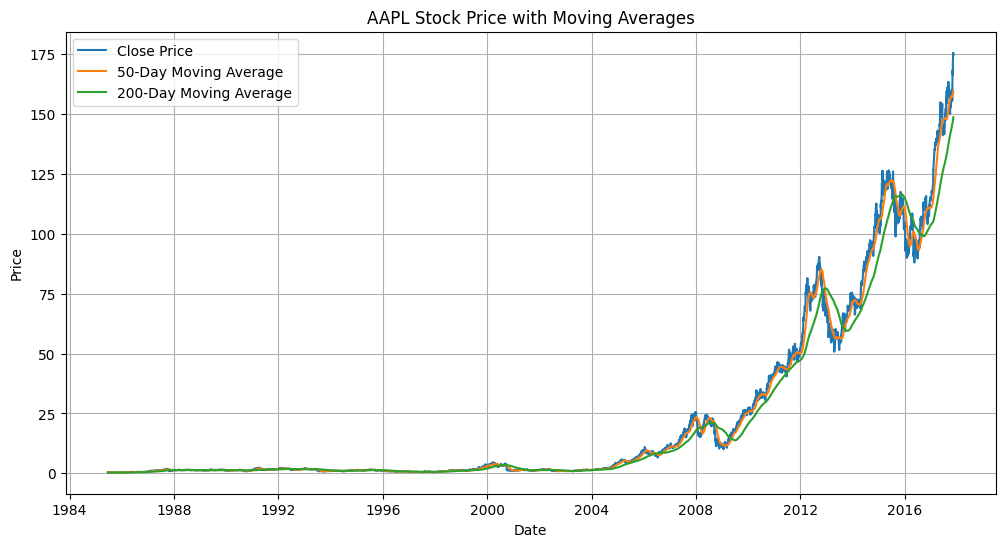

In [19]:
# 14. Plot closing price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Close Price')
plt.plot(data.index, data['MA50'], label='50-Day Moving Average')
plt.plot(data.index, data['MA200'], label='200-Day Moving Average')
plt.title("AAPL Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

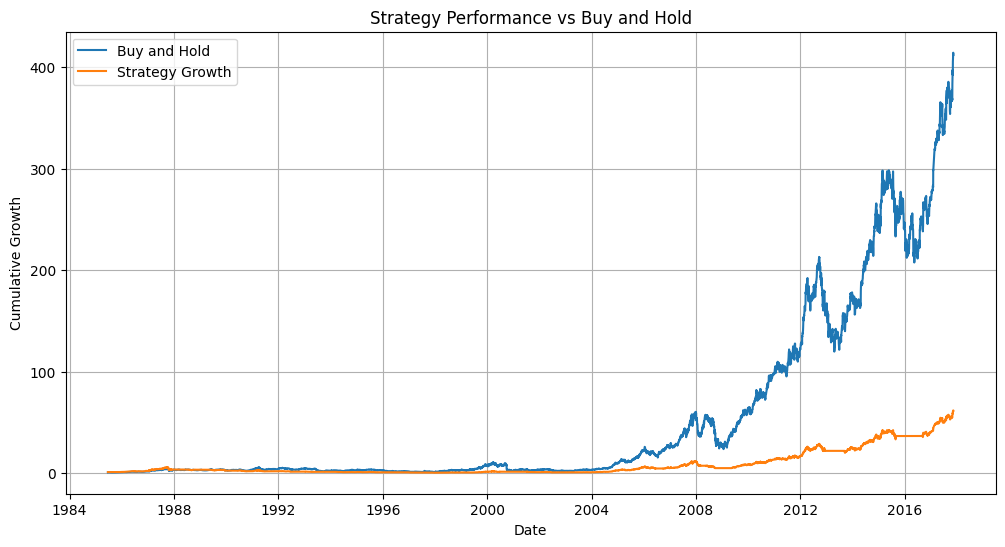

In [20]:
# 15. Plot strategy vs buy and hold
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Buy and Hold'], label='Buy and Hold')
plt.plot(data.index, data['Strategy Growth'], label='Strategy Growth')
plt.title("Strategy Performance vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True)
plt.show()